In [1]:
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

In [2]:
data =  pd.read_csv(r"D:\ML\Neural Nets\ca314bf7-7b52-49f0-a69d-be26c884696e-FCFNNs-Demonstration-Files\FCFNNs - Demonstration Files\train.csv")
X_test = pd.read_csv(r"D:\ML\Neural Nets\ca314bf7-7b52-49f0-a69d-be26c884696e-FCFNNs-Demonstration-Files\FCFNNs - Demonstration Files\test.csv")
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data_y = data['label'].values
data_x = data.drop(['label'], axis=1)

In [4]:
data_x.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
np.unique(data_y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

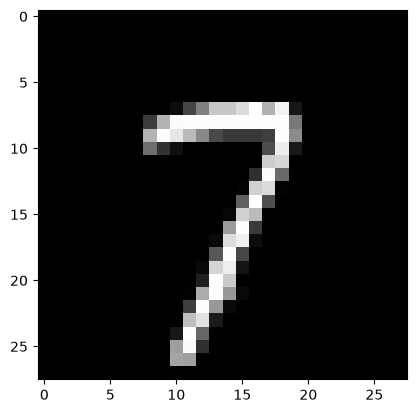

In [9]:
img = data_x.iloc[18].values.reshape(28,28)
plt.imshow(img, cmap='gray')

In [33]:
model = keras.Sequential([
    keras.layers.Dense(128,activation = tf.nn.relu, input_shape=(784,)),
    keras.layers.Dense(128,activation = tf.nn.relu),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128,activation = tf.nn.relu),
    keras.layers.Dense(10,activation = tf.nn.softmax)
])

In [34]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
X_train, X_val, y_train, y_val = train_test_split(data_x, data_y, test_size=0.1, random_state=42)

In [37]:
X_train.shape[0]/64

590.625

In [38]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val),batch_size=64, verbose=1)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7912 - loss: 2.1963 - val_accuracy: 0.8900 - val_loss: 0.4819
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8949 - loss: 0.4428 - val_accuracy: 0.9321 - val_loss: 0.3057
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9241 - loss: 0.2972 - val_accuracy: 0.9383 - val_loss: 0.2397
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9404 - loss: 0.2190 - val_accuracy: 0.9452 - val_loss: 0.2325
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9483 - loss: 0.1927 - val_accuracy: 0.9467 - val_loss: 0.2221
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9526 - loss: 0.1661 - val_accuracy: 0.9543 - val_loss: 0.1794
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9580 - loss: 0.1513 - val_accuracy: 0.9512 - val_loss: 0.1673
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9608 - loss: 0.1370 - val_accuracy: 0.

In [39]:
model.history.history['accuracy']

[0.7912433743476868,
 0.8949471116065979,
 0.9241269826889038,
 0.9403703808784485,
 0.9483068585395813,
 0.9526190757751465,
 0.9579629898071289,
 0.9608465433120728,
 0.9637301564216614,
 0.9688624143600464]

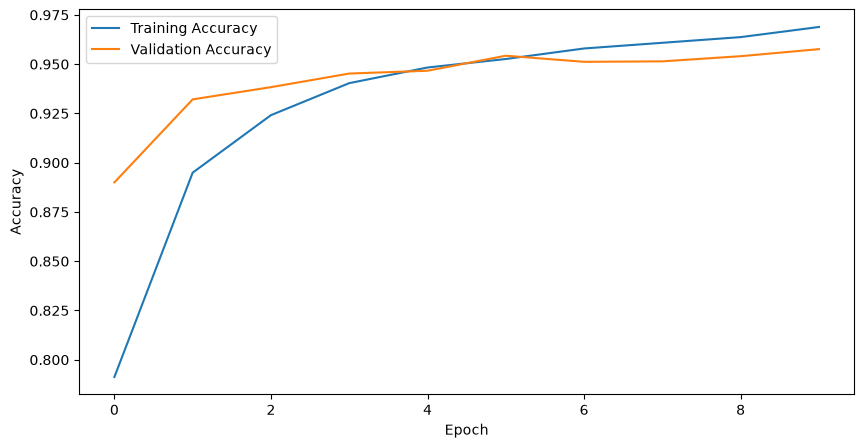

In [40]:
plt.figure(figsize=(10,5))
plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [41]:
model.predict(X_test).argmax(axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step


array([2, 0, 9, ..., 3, 9, 2], shape=(28000,))

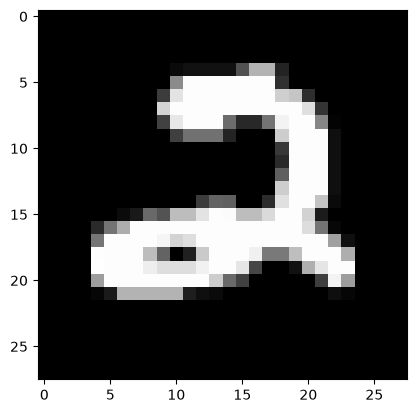

In [42]:
img = X_test.iloc[0].values.reshape(28,28)
plt.imshow(img, cmap='gray')